# Nhiệm vụ 2: Tìm tham số tối ưu cho cây quyết định bằng GridSearchCV và vẽ biểu đồ đánh giá mô hình với các tham số khác nhau

## Bước 1: Cài đặt các thư viện cần thiết

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import graphviz
from sklearn.model_selection import train_test_split
from sklearn import tree

%matplotlib inline
mpl.rcParams['figure.dpi'] = 400  # Độ phân giải cao

## Bước 2: Nạp dữ liệu và loại bỏ các cột không cần thiết

In [2]:
df = pd.read_csv("default_of_credit_card_clients.csv")

features_response = df.columns.tolist()

# Danh sách các cột không dùng
items_to_remove = ['ID', 'SEX', 'PAY_2', 'PAY_3',
                   'PAY_4', 'PAY_5', 'PAY_6',
                   'EDUCATION_CAT', 'graduate school',
                   'high school', 'none',
                   'others', 'university']

features_response = [item for item in features_response if item not in items_to_remove]
print(features_response)


['LIMIT_BAL', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


## Bước 3: Chia dữ liệu Train/Test

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    df[features_response[:-1]].values,
    df['default payment next month'].values,
    test_size=0.2,
    random_state=24
)

## Bước 4: Dò tìm tham số tốt nhất

In [4]:
from sklearn.model_selection import GridSearchCV

params = {'max_depth': [1, 2, 4, 6, 8, 10, 12]}
dt = tree.DecisionTreeClassifier()

cv = GridSearchCV(
    dt, param_grid=params,
    scoring='roc_auc',
    cv=4, refit=True,
    return_train_score=True,
    verbose=1
)
cv.fit(X_train, y_train)


Fitting 4 folds for each of 7 candidates, totalling 28 fits


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [1, 2, 4, 6, 8, 10, 12]},
             return_train_score=True, scoring='roc_auc', verbose=1)

## Bước 5: Vẽ biểu đồ đánh giá các tham số khác nhau

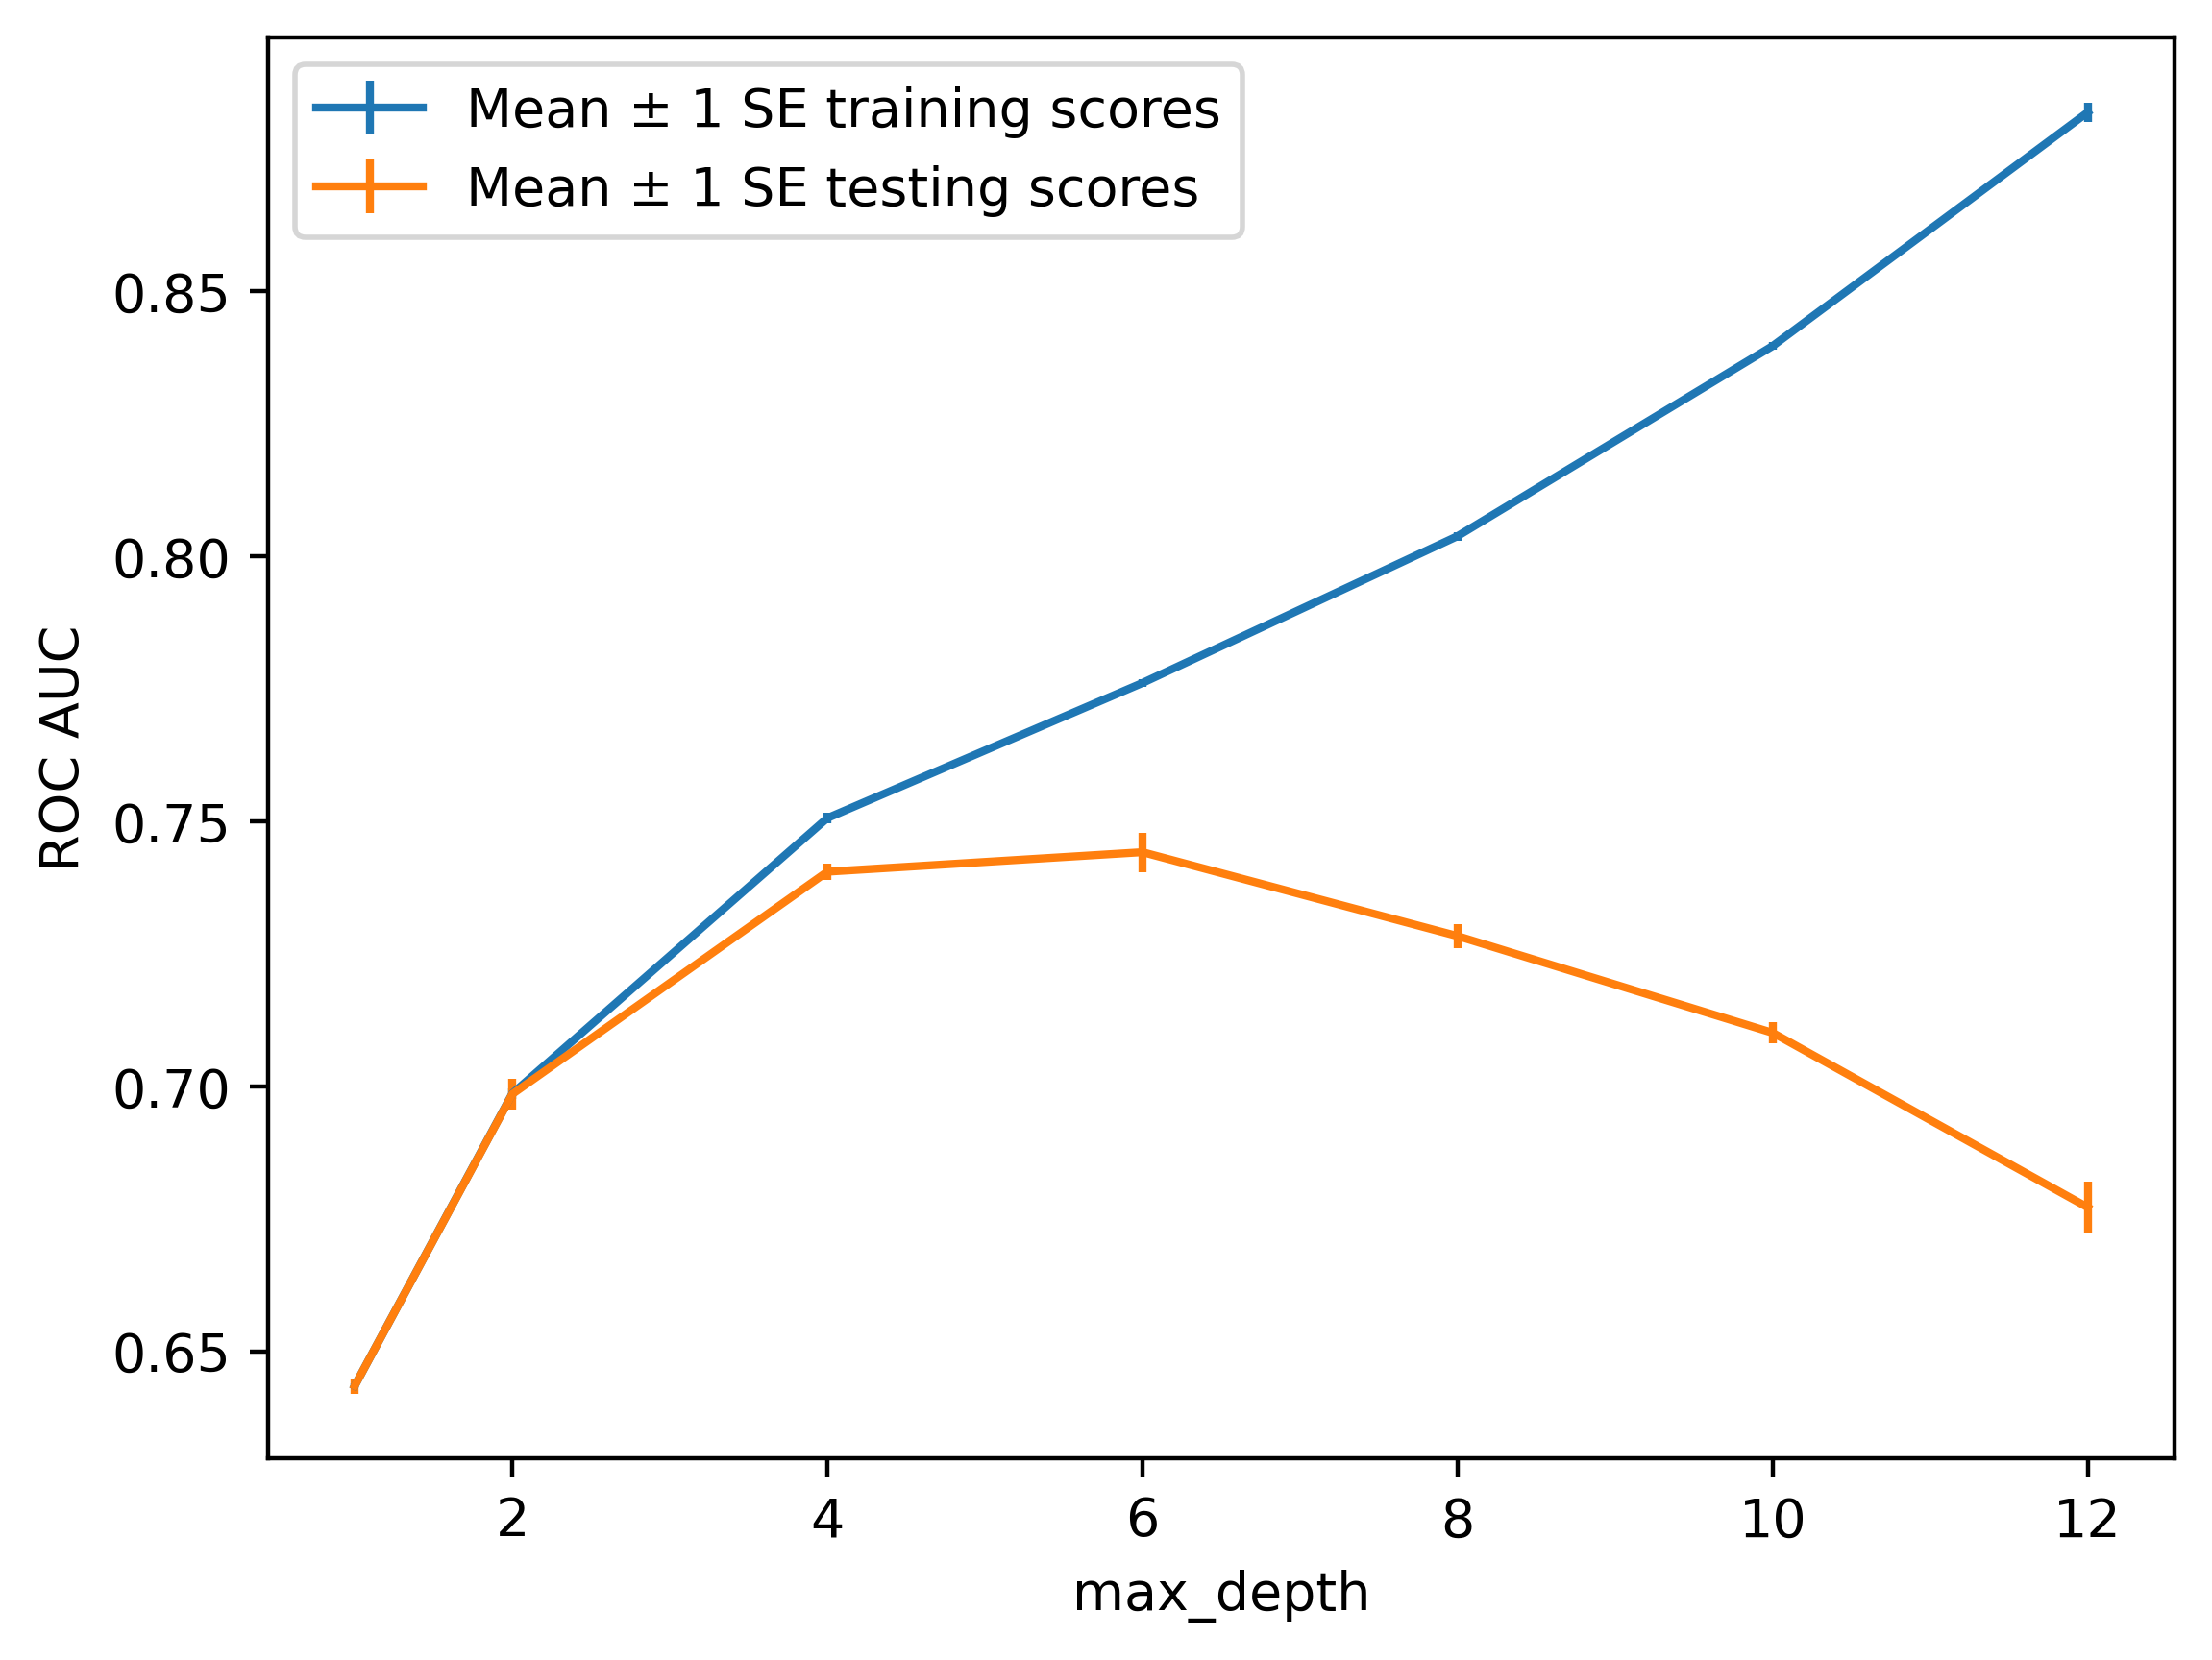

In [5]:
cv_results_df = pd.DataFrame(cv.cv_results_)

ax = plt.axes()
ax.errorbar(cv_results_df['param_max_depth'],
             cv_results_df['mean_train_score'],
             yerr=cv_results_df['std_train_score']/np.sqrt(4),
             label='Mean ± 1 SE training scores')

ax.errorbar(cv_results_df['param_max_depth'],
             cv_results_df['mean_test_score'],
             yerr=cv_results_df['std_test_score']/np.sqrt(4),
             label='Mean ± 1 SE testing scores')

ax.legend()
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')
plt.show()
